In [ ]:
# File list
files = [
    "data/trades_round_1_day_-2.csv",
    "data/trades_round_2_day_-1.csv",
    "data/trades_round_3_day_0.csv",
    "data/trades_round_4_day_1.csv",
    "data/trades_round_5_day_2.csv",
    "data/trades_round_5_day_3.csv",
    "data/trades_round_5_day_4.csv",
]

df_list = []
timestamp_offset = 0

for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';')
        df['timestamp'] += timestamp_offset
        timestamp_offset = df['timestamp'].max() + 1
        df_list.append(df)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set Matplotlib style for better visualizations
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Load trades from consecutive days
def load_consecutive_trades(file_list):
    """
    Load and merge trade data from consecutive trading day CSV files.

    Parameters:
    file_list (list): List of CSV file paths (in trading day order).

    Returns:
    pd.DataFrame: Merged trade data.
    """
    dfs = []
    offset = 0

    for file in file_list:
        df = pd.read_csv(file, delimiter=';')

        # Ensure integer timestamp and apply offset
        df['timestamp'] = df['timestamp'].astype(int) + offset
        offset = df['timestamp'].max() + 100  # maintain continuity

        dfs.append(df)

    merged_df = pd.concat(dfs, ignore_index=True)

    # Convert numeric fields
    for col in ['price', 'quantity', 'timestamp']:
        merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

    return merged_df

# List of consecutive day files (ensure they are in chronological order)
file_list = [
    "data/trades_round_5_day_2.csv",
    "data/trades_round_5_day_3.csv",
    "data/trades_round_5_day_4.csv"
]

# Load and display merged trades
trades_df = load_consecutive_trades(file_list)
print(f"Merged {len(trades_df)} trades from {len(file_list)} files.\n")
print(trades_df.head())


Merged 53477 trades from 3 files.

   timestamp    buyer   seller            symbol   currency   price  quantity
0          0   Caesar    Paris        CROISSANTS  SEASHELLS  4265.0         8
1        100  Charlie    Paris  RAINFOREST_RESIN  SEASHELLS  9999.0         1
2        200    Paris   Caesar        CROISSANTS  SEASHELLS  4266.0         8
3        200    Paris   Caesar              JAMS  SEASHELLS  6520.0         7
4        200    Paris  Charlie              KELP  SEASHELLS  2046.0         1


In [10]:
# 2. Analyze overall trade statistics
print("\n--- Overall Trading Statistics ---")
total_trades = len(trades_df)
total_volume = trades_df['quantity'].sum()
unique_products = trades_df['symbol'].nunique()
unique_traders = len(set(trades_df['buyer'].unique()) | set(trades_df['seller'].unique()))

print(f"Total trades: {total_trades}")
print(f"Total trading volume: {total_volume}")
print(f"Unique products traded: {unique_products}")
print(f"Unique traders: {unique_traders}")


--- Overall Trading Statistics ---
Total trades: 53477
Total trading volume: 301127
Unique products traded: 15
Unique traders: 11



--- Trader Activity Analysis ---

Trader activity summary:


,Buy Count,Sell Count,Total Trades,Buy/Sell Ratio
Caesar,12598.0,16931,29529.0,0.744079
Paris,10512.0,12135,22647.0,0.866255
Camilla,13053.0,5885,18938.0,2.218012
Charlie,10123.0,7183,17306.0,1.409300
Pablo,2141.0,5672,7813.0,0.377468
Penelope,3666.0,3872,7538.0,0.946798
Gary,777.0,757,1534.0,1.026420
Gina,406.0,812,1218.0,0.500000
Peter,191.0,219,410.0,0.872146
Olivia,10.0,10,20.0,1.000000


<Figure size 1400x800 with 0 Axes>

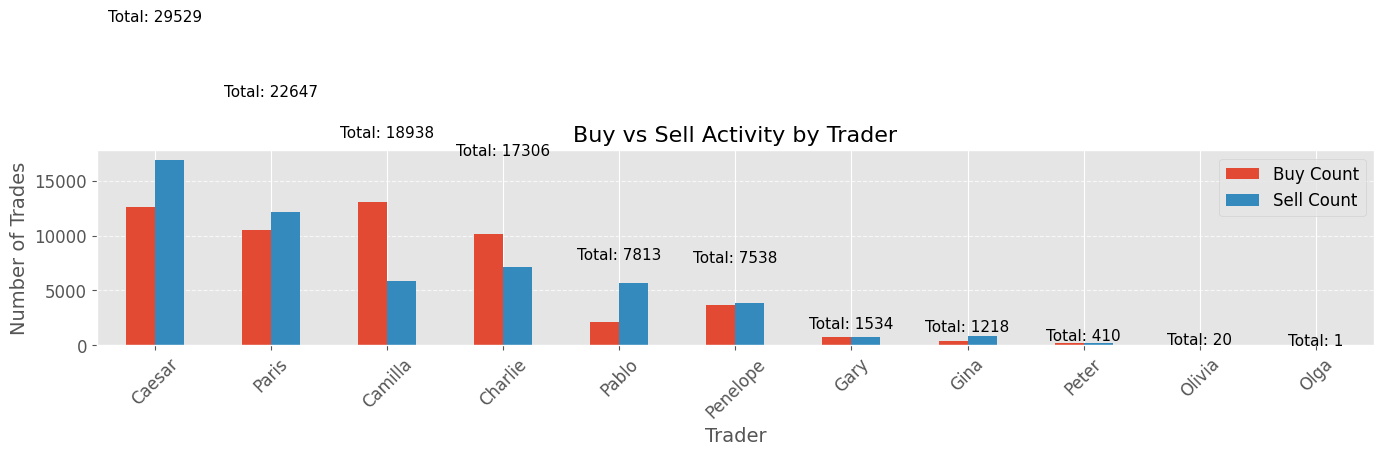


Trading volume by trader:


,Buy Volume,Sell Volume,Total Volume
Caesar,55726.0,132125,187851.0
Camilla,136275.0,36863,173138.0
Paris,29531.0,31965,61496.0
Charlie,33711.0,26978,60689.0
Penelope,28792.0,29891,58683.0
Pablo,6750.0,30151,36901.0
Gary,6685.0,6381,13066.0
Gina,2119.0,5032,7151.0
Peter,1439.0,1633,3072.0
Olivia,99.0,99,198.0


<Figure size 1400x800 with 0 Axes>

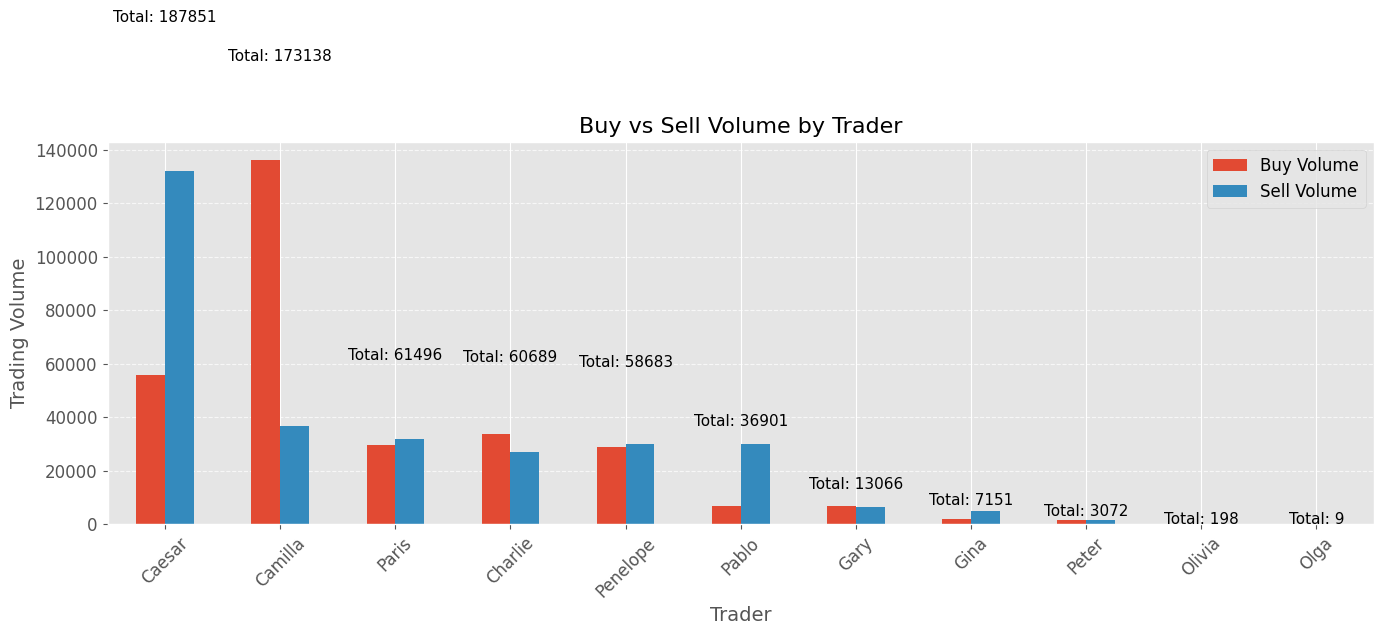

In [11]:
# 3. Analyze trader activity
print("\n--- Trader Activity Analysis ---")

# Count trades where each trader is the buyer or seller
buyer_counts = trades_df['buyer'].value_counts()
seller_counts = trades_df['seller'].value_counts()

# Combine buyer and seller counts
trader_activity = pd.DataFrame({
    'Buy Count': buyer_counts,
    'Sell Count': seller_counts
}).fillna(0)

# Calculate total trades and buy/sell ratio
trader_activity['Total Trades'] = trader_activity['Buy Count'] + trader_activity['Sell Count']
trader_activity['Buy/Sell Ratio'] = trader_activity['Buy Count'] / trader_activity['Sell Count'].replace(0, 1)  # Avoid division by zero
trader_activity = trader_activity.sort_values('Total Trades', ascending=False)

print("\nTrader activity summary:")
display(trader_activity)

# Plot trader activity
plt.figure(figsize=(14, 8))
ax = trader_activity[['Buy Count', 'Sell Count']].plot(kind='bar', figsize=(14, 7))
plt.title('Buy vs Sell Activity by Trader', fontsize=16)
plt.xlabel('Trader', fontsize=14)
plt.ylabel('Number of Trades', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add total count labels on top of bars
for i, total in enumerate(trader_activity['Total Trades']):
    plt.text(i, trader_activity['Buy Count'].iloc[i] + trader_activity['Sell Count'].iloc[i] + 5, 
             f'Total: {total:.0f}', 
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Calculate trading volume by trader
volume_by_buyer = trades_df.groupby('buyer')['quantity'].sum()
volume_by_seller = trades_df.groupby('seller')['quantity'].sum()

trading_volume = pd.DataFrame({
    'Buy Volume': volume_by_buyer,
    'Sell Volume': volume_by_seller
}).fillna(0)
trading_volume['Total Volume'] = trading_volume['Buy Volume'] + trading_volume['Sell Volume']
trading_volume = trading_volume.sort_values('Total Volume', ascending=False)

print("\nTrading volume by trader:")
display(trading_volume)

# Plot trading volume by trader
plt.figure(figsize=(14, 8))
trading_volume[['Buy Volume', 'Sell Volume']].plot(kind='bar', figsize=(14, 7))
plt.title('Buy vs Sell Volume by Trader', fontsize=16)
plt.xlabel('Trader', fontsize=14)
plt.ylabel('Trading Volume', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add total volume labels
for i, total in enumerate(trading_volume['Total Volume']):
    plt.text(i, trading_volume['Buy Volume'].iloc[i] + trading_volume['Sell Volume'].iloc[i] + 5, 
             f'Total: {total:.0f}', 
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()


--- Product Trading Analysis ---

Product trading summary:


,Trades,Volume,Avg Price,Price Volatility
symbol,,,,
SQUID_INK,8719,25146,1880.916045,78.719013
KELP,8708,25003,2035.113000,13.181869
RAINFOREST_RESIN,5558,18640,10000.066391,5.857348
JAMS,3534,24985,6485.514431,31.507850
VOLCANIC_ROCK_VOUCHER_9750,3508,35620,325.985462,116.604169
VOLCANIC_ROCK_VOUCHER_9500,3444,34882,570.224448,121.245027
VOLCANIC_ROCK_VOUCHER_10000,3246,32878,130.581947,78.256376
DJEMBES,3111,10634,13342.252652,45.047989
CROISSANTS,2950,19359,4265.945424,20.152001


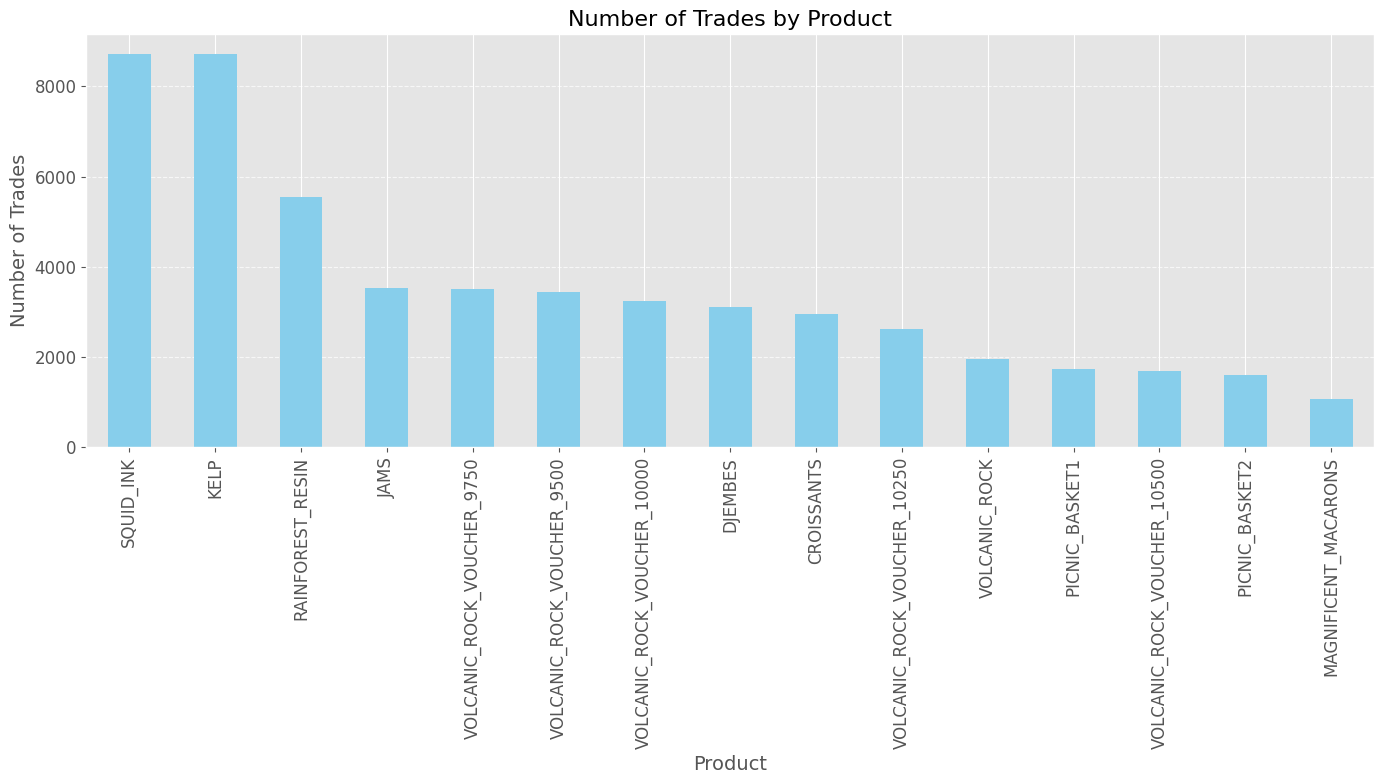

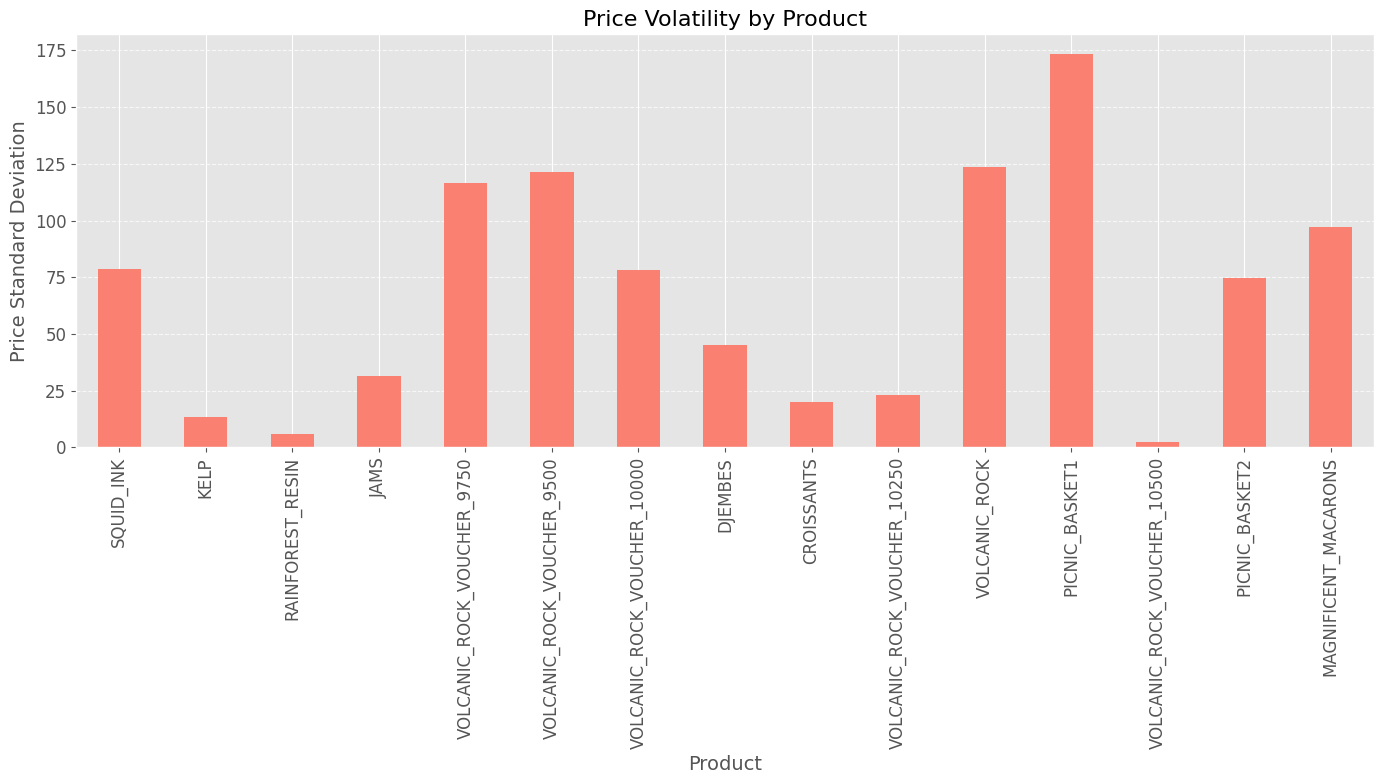

In [12]:
# 4. Analyze product trading patterns
print("\n--- Product Trading Analysis ---")

# Count trades by product
product_trades = trades_df['symbol'].value_counts()
products_df = pd.DataFrame({'Trades': product_trades})

# Get volume by product
product_volume = trades_df.groupby('symbol')['quantity'].sum()
products_df['Volume'] = product_volume

# Calculate average price by product
product_avg_price = trades_df.groupby('symbol')['price'].mean()
products_df['Avg Price'] = product_avg_price

# Calculate price volatility (std dev)
product_price_std = trades_df.groupby('symbol')['price'].std()
products_df['Price Volatility'] = product_price_std

products_df = products_df.sort_values('Trades', ascending=False)

print("\nProduct trading summary:")
display(products_df)

# Plot number of trades by product
plt.figure(figsize=(14, 8))
products_df['Trades'].plot(kind='bar', color='skyblue')
plt.title('Number of Trades by Product', fontsize=16)
plt.xlabel('Product', fontsize=14)
plt.ylabel('Number of Trades', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot price volatility by product
plt.figure(figsize=(14, 8))
products_df['Price Volatility'].plot(kind='bar', color='salmon')
plt.title('Price Volatility by Product', fontsize=16)
plt.xlabel('Product', fontsize=14)
plt.ylabel('Price Standard Deviation', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Trader Product Specialization ---

Top products each trader buys:
Caesar: JAMS, CROISSANTS, VOLCANIC_ROCK
Camilla: VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500, VOLCANIC_ROCK_VOUCHER_10000
Charlie: SQUID_INK, KELP, RAINFOREST_RESIN
Gary: SQUID_INK, KELP, RAINFOREST_RESIN
Gina: RAINFOREST_RESIN, KELP, SQUID_INK
Olivia: KELP, SQUID_INK, CROISSANTS
Pablo: RAINFOREST_RESIN, PICNIC_BASKET1, KELP
Paris: JAMS, CROISSANTS, DJEMBES
Penelope: VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500, SQUID_INK
Peter: VOLCANIC_ROCK

Top products each trader sells:
Caesar: VOLCANIC_ROCK_VOUCHER_10000, VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500
Camilla: JAMS, VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500
Charlie: KELP, SQUID_INK, RAINFOREST_RESIN
Gary: KELP, SQUID_INK, RAINFOREST_RESIN
Gina: SQUID_INK, KELP, RAINFOREST_RESIN
Olga: KELP
Olivia: KELP, SQUID_INK, CROISSANTS
Pablo: VOLCANIC_ROCK_VOUCHER_10500, VOLCANIC_ROCK_VOUCHER_9500, VOLCANIC_ROCK_VOUCHER_10250
Pari

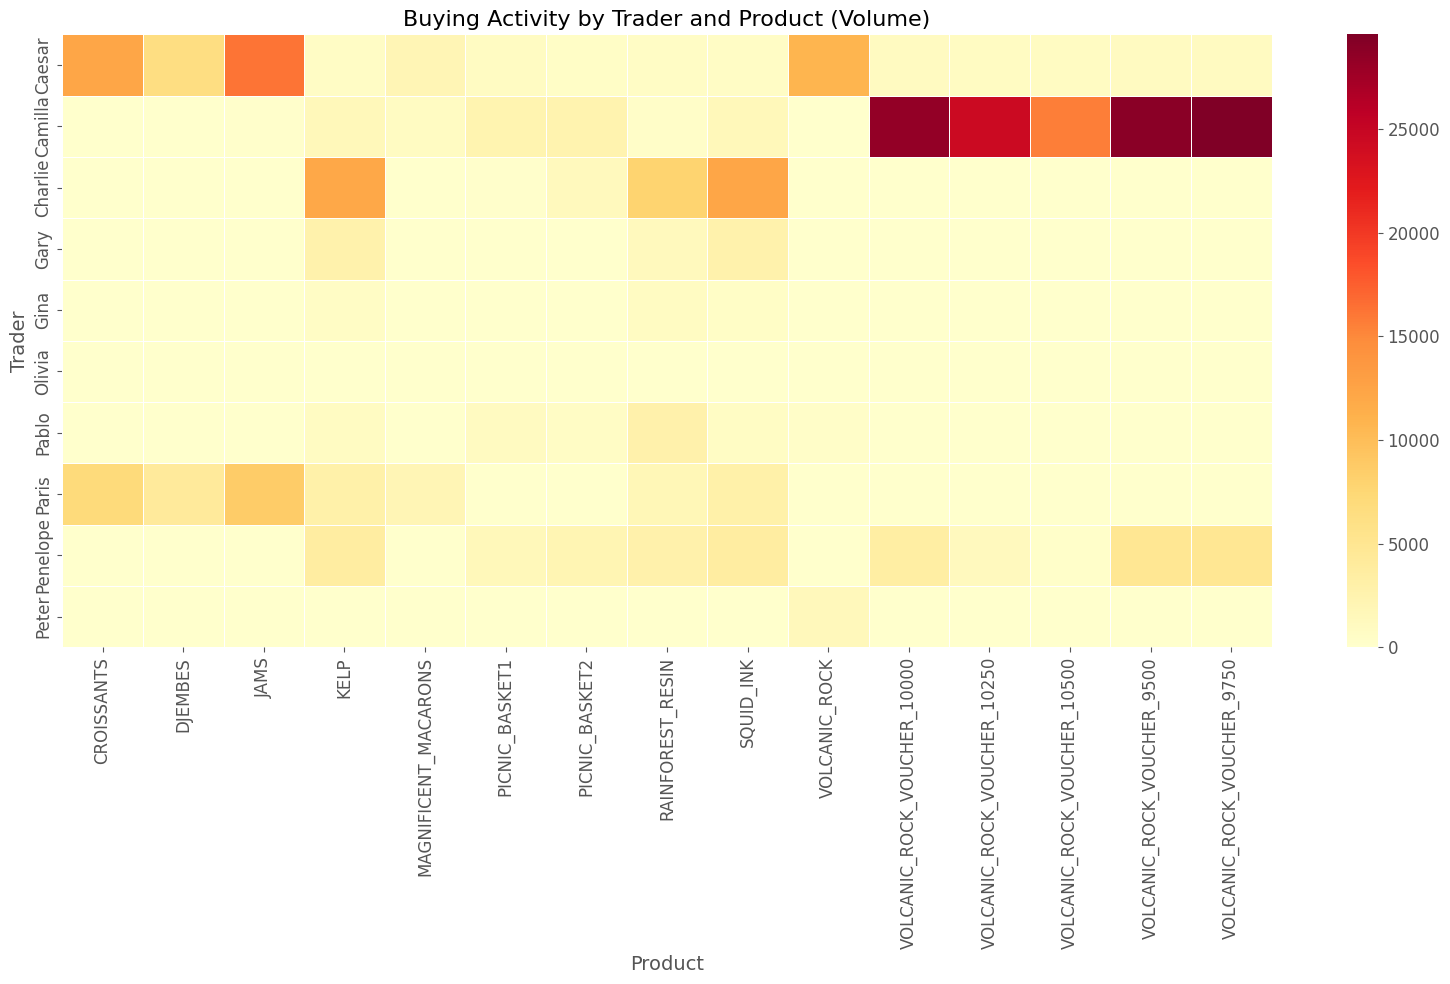

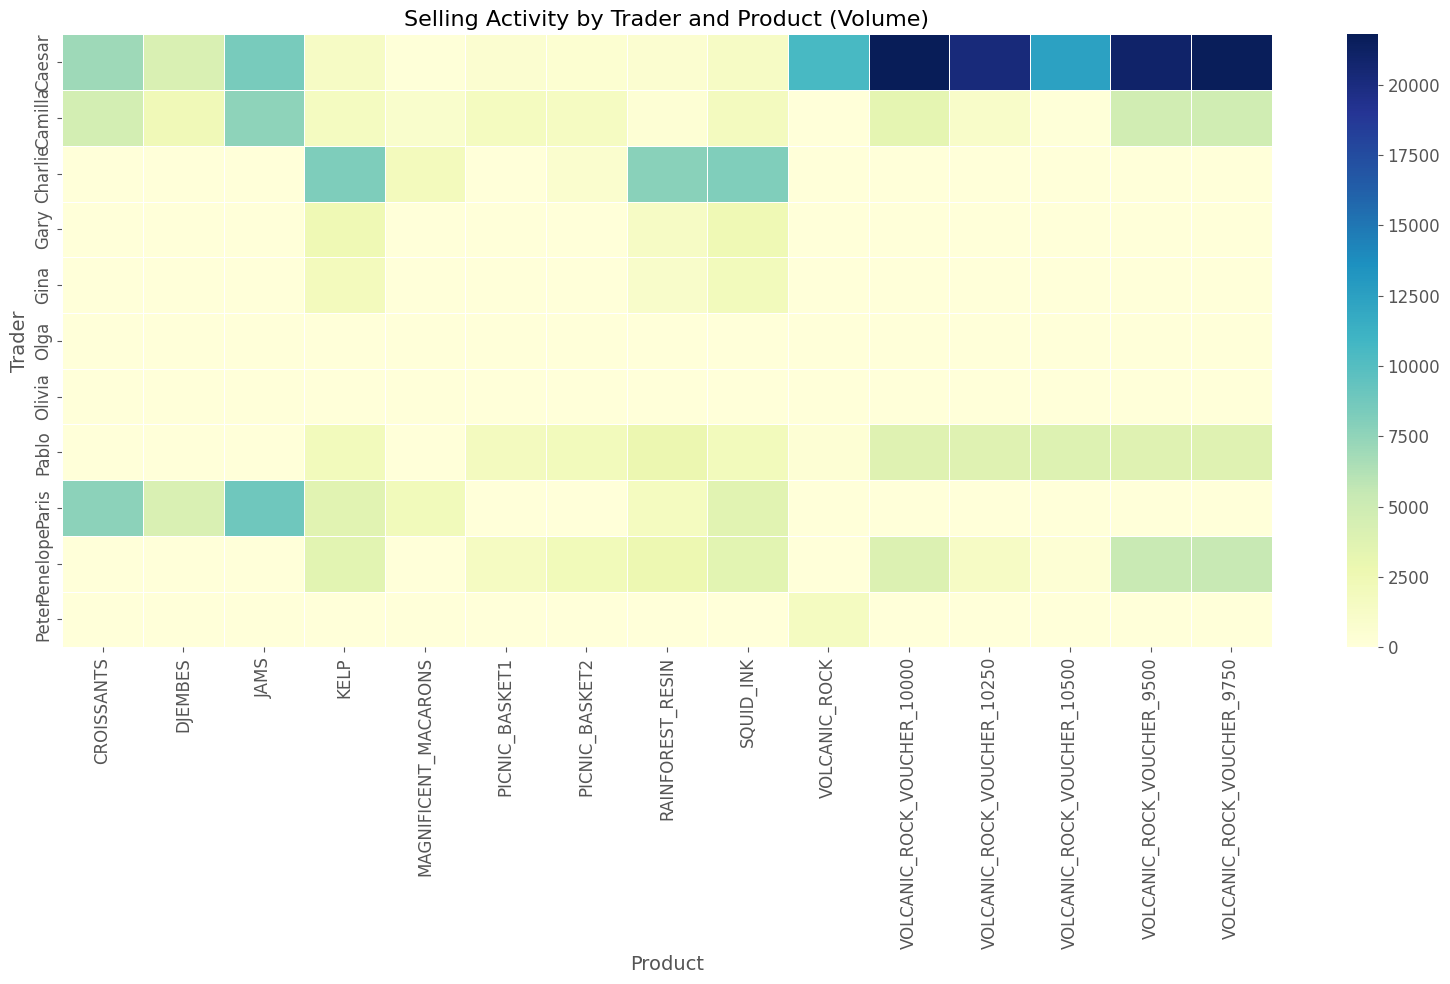

In [13]:
# 5. Trader activity by product
print("\n--- Trader Product Specialization ---")

# Create a matrix of trader activity by product
buyer_product_matrix = pd.crosstab(trades_df['buyer'], trades_df['symbol'], values=trades_df['quantity'], aggfunc='sum')
seller_product_matrix = pd.crosstab(trades_df['seller'], trades_df['symbol'], values=trades_df['quantity'], aggfunc='sum')

# Fill NAs with zeros
buyer_product_matrix = buyer_product_matrix.fillna(0)
seller_product_matrix = seller_product_matrix.fillna(0)

# Function to get top products for each trader
def get_top_products(trader_df, n=3):
    top_products = {}
    for trader in trader_df.index:
        trader_prods = trader_df.loc[trader].sort_values(ascending=False)
        top_prods = trader_prods[trader_prods > 0].head(n).index.tolist()
        if top_prods:
            top_products[trader] = top_prods
    return top_products

# Get top products for buyers and sellers
top_buy_products = get_top_products(buyer_product_matrix)
top_sell_products = get_top_products(seller_product_matrix)

print("\nTop products each trader buys:")
for trader, products in top_buy_products.items():
    print(f"{trader}: {', '.join(products)}")

print("\nTop products each trader sells:")
for trader, products in top_sell_products.items():
    print(f"{trader}: {', '.join(products)}")

# Create a heatmap of buyer activity by product
plt.figure(figsize=(16, 10))
sns.heatmap(buyer_product_matrix, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Buying Activity by Trader and Product (Volume)', fontsize=16)
plt.xlabel('Product', fontsize=14)
plt.ylabel('Trader', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Create a heatmap of seller activity by product
plt.figure(figsize=(16, 10))
sns.heatmap(seller_product_matrix, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Selling Activity by Trader and Product (Volume)', fontsize=16)
plt.xlabel('Product', fontsize=14)
plt.ylabel('Trader', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


--- Price Analysis by Trader ---

Traders who buy at favorable prices (above market average):

CROISSANTS:
  Paris: 4268.00

RAINFOREST_RESIN:
  Penelope: 10006.79
  Gary: 10006.74
  Paris: 10003.97
  Pablo: 10003.84
  Gina: 10002.30

JAMS:
  Paris: 6485.55
  Caesar: 6485.52

KELP:
  Gina: 2037.54
  Gary: 2036.89
  Penelope: 2036.60
  Paris: 2036.40
  Pablo: 2035.67
  Caesar: 2035.51

SQUID_INK:
  Gary: 1888.44
  Paris: 1883.84
  Penelope: 1883.23
  Pablo: 1881.37
  Camilla: 1881.01

PICNIC_BASKET1:
  Charlie: 58412.94
  Penelope: 58370.71

PICNIC_BASKET2:
  Penelope: 30113.71
  Pablo: 30111.56
  Camilla: 30110.34

MAGNIFICENT_MACARONS:
  Paris: 715.99
  Caesar: 710.84

DJEMBES:
  Camilla: 13365.00
  Paris: 13343.12

VOLCANIC_ROCK_VOUCHER_10000:
  Pablo: 155.00
  Penelope: 154.72
  Caesar: 131.21

VOLCANIC_ROCK_VOUCHER_10250:
  Penelope: 45.63

VOLCANIC_ROCK_VOUCHER_10500:
  Caesar: 3.58
  Camilla: 3.55

VOLCANIC_ROCK_VOUCHER_9500:
  Caesar: 574.58

VOLCANIC_ROCK_VOUCHER_9750:
  Pablo

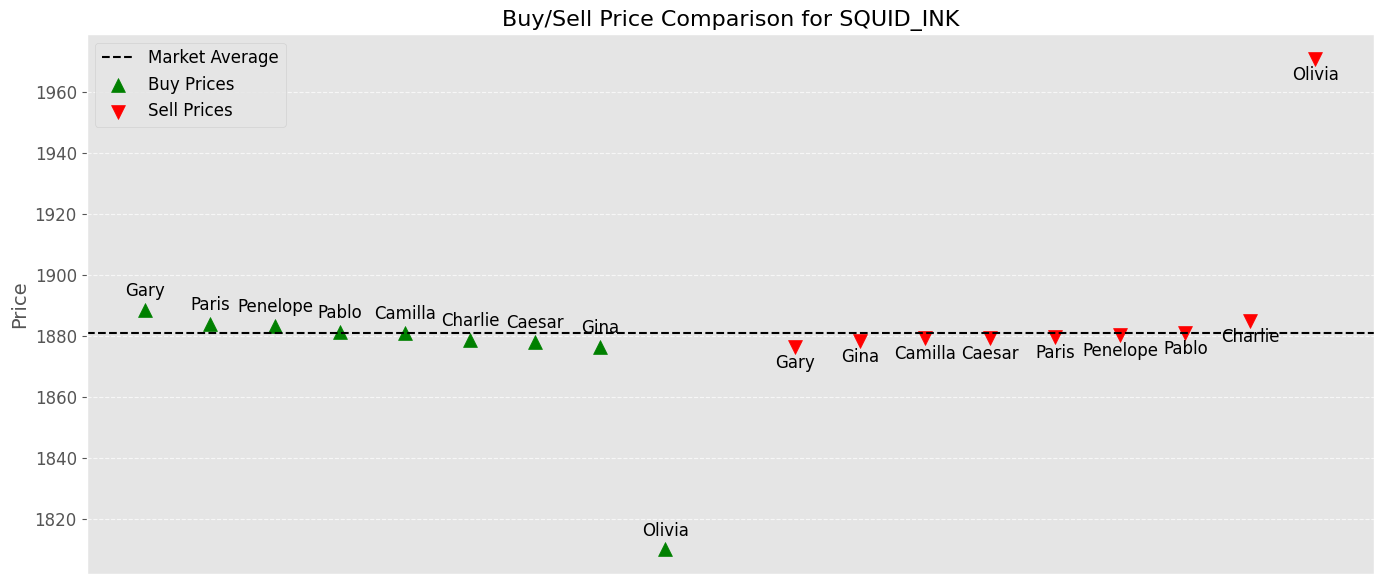

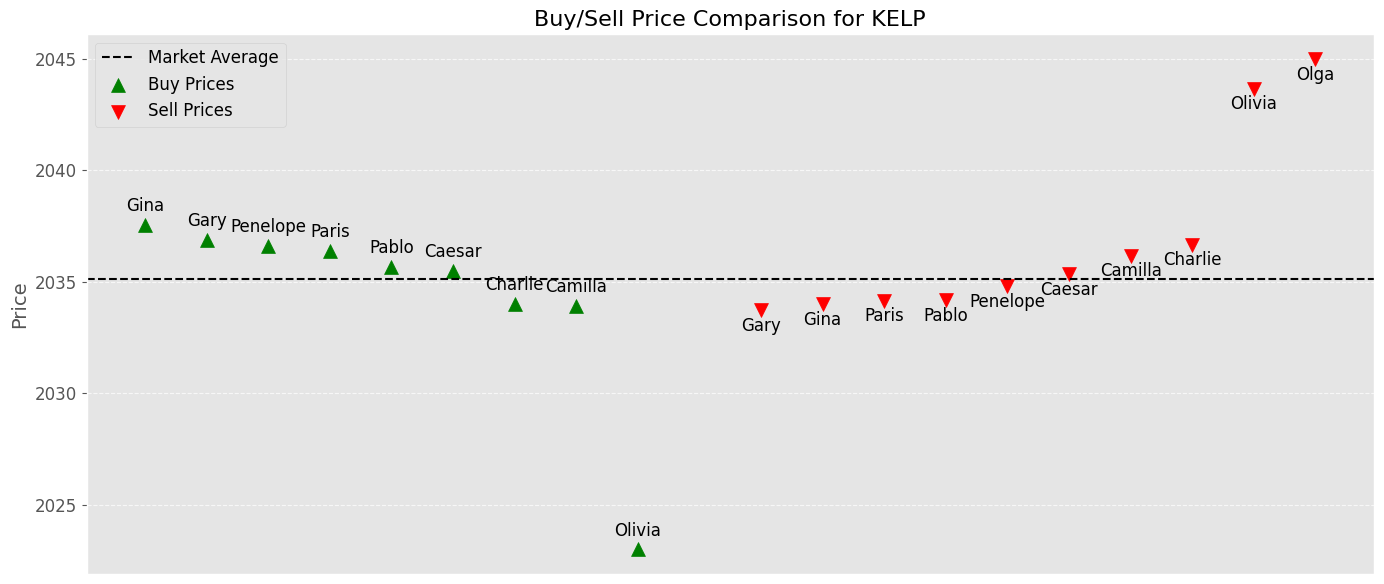

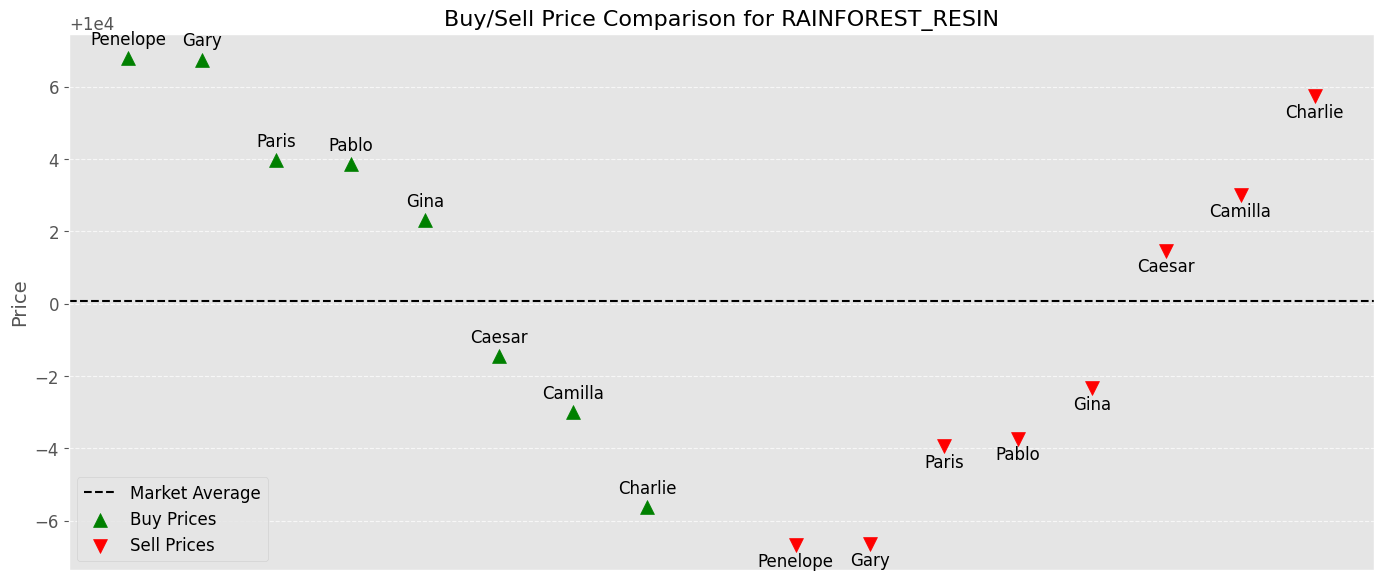

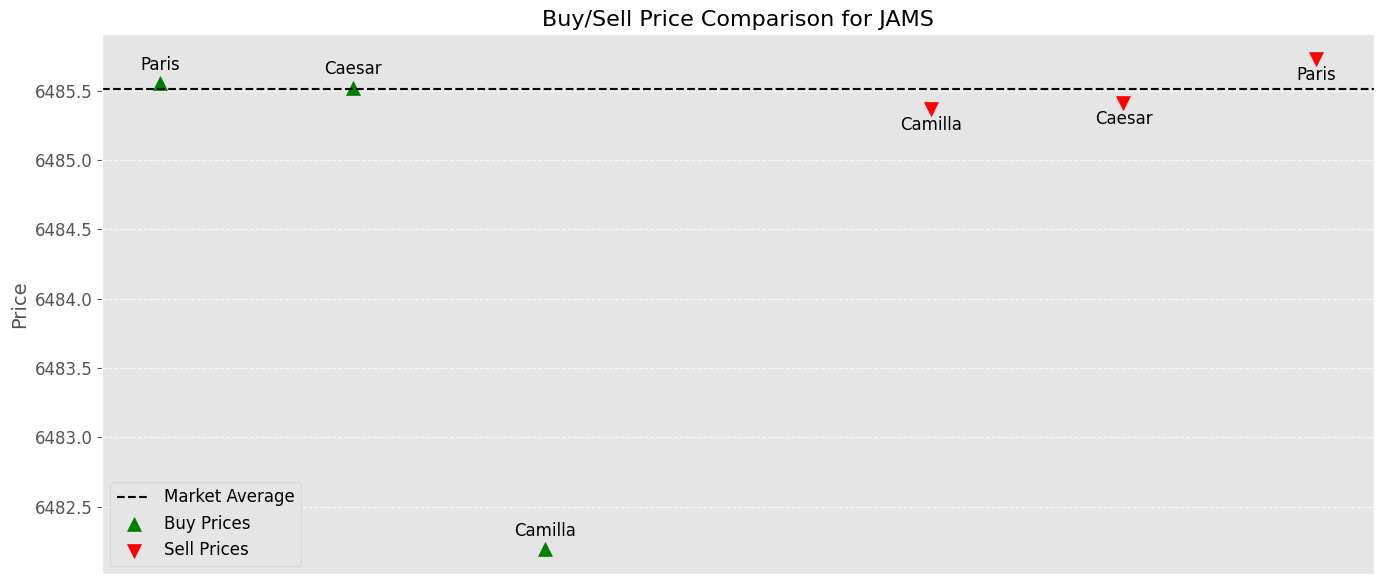

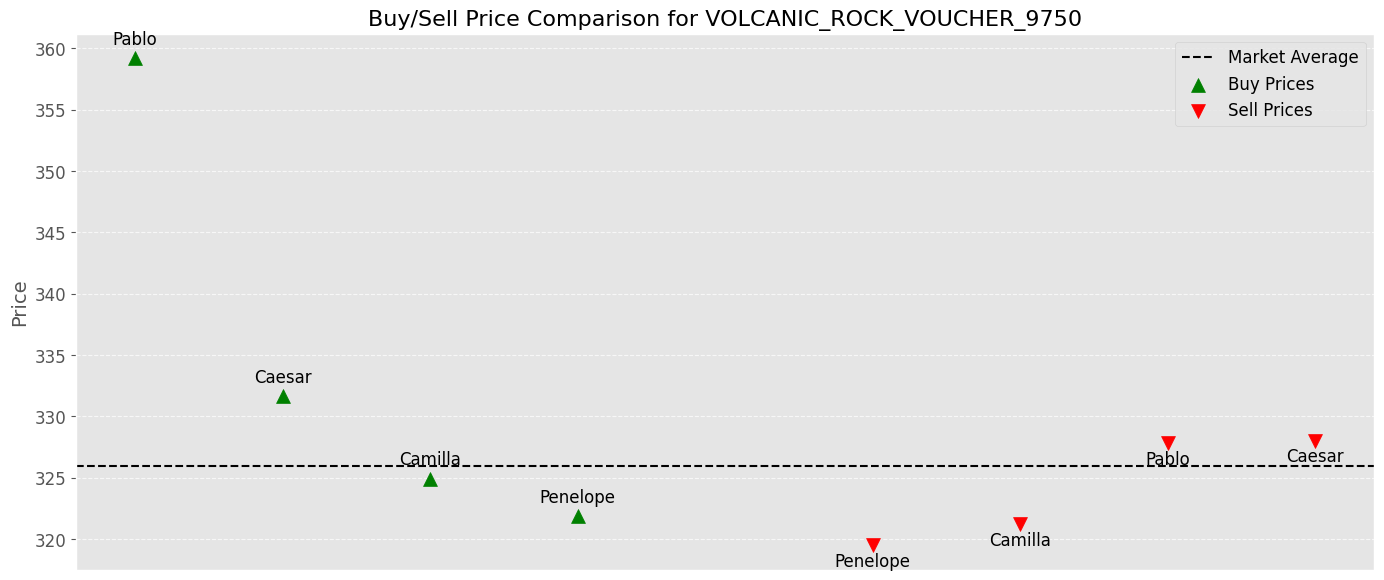

In [14]:
# 6. Price Analysis by Trader and Product
print("\n--- Price Analysis by Trader ---")

# Average buy prices by product and trader
buy_prices = trades_df.groupby(['symbol', 'buyer'])['price'].mean().unstack()
sell_prices = trades_df.groupby(['symbol', 'seller'])['price'].mean().unstack()

# Calculate market average price by product
market_avg_price = trades_df.groupby('symbol')['price'].mean()

# Find traders who buy above market average (good to sell to)
favorable_buyers = {}
for product in trades_df['symbol'].unique():
    if product in buy_prices.index:
        product_buyers = buy_prices.loc[product].dropna()
        if len(product_buyers) > 0:
            market_avg = market_avg_price[product]
            good_buyers = product_buyers[product_buyers > market_avg].sort_values(ascending=False)
            if not good_buyers.empty:
                favorable_buyers[product] = good_buyers.to_dict()

# Find traders who sell below market average (good to buy from)
favorable_sellers = {}
for product in trades_df['symbol'].unique():
    if product in sell_prices.index:
        product_sellers = sell_prices.loc[product].dropna()
        if len(product_sellers) > 0:
            market_avg = market_avg_price[product]
            good_sellers = product_sellers[product_sellers < market_avg].sort_values()
            if not good_sellers.empty:
                favorable_sellers[product] = good_sellers.to_dict()

print("\nTraders who buy at favorable prices (above market average):")
for product, buyers in favorable_buyers.items():
    if buyers:
        print(f"\n{product}:")
        for trader, price in buyers.items():
            print(f"  {trader}: {price:.2f}")

print("\nTraders who sell at favorable prices (below market average):")
for product, sellers in favorable_sellers.items():
    if sellers:
        print(f"\n{product}:")
        for trader, price in sellers.items():
            print(f"  {trader}: {price:.2f}")

# Plot price spreads by product and trader
def plot_price_spreads(product, buy_df, sell_df, market_avg):
    """Plot the buying and selling prices for a product by trader"""
    if product not in buy_df.index or product not in sell_df.index:
        return
    
    buy_data = buy_df.loc[product].dropna()
    sell_data = sell_df.loc[product].dropna()
    
    if buy_data.empty and sell_data.empty:
        return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot horizontal line for market average
    ax.axhline(y=market_avg[product], color='black', linestyle='--', label='Market Average')
    
    # Plot buy prices
    if not buy_data.empty:
        buy_data = buy_data.sort_values(ascending=False)
        ax.scatter(range(len(buy_data)), buy_data.values, 
                  color='green', s=100, marker='^', label='Buy Prices')
        
        # Add trader labels
        for i, (trader, price) in enumerate(buy_data.items()):
            ax.annotate(trader, (i, price), xytext=(0, 10), 
                       textcoords='offset points', ha='center')
    
    # Plot sell prices
    if not sell_data.empty:
        sell_data = sell_data.sort_values()
        offset = 0 if buy_data.empty else len(buy_data) + 1
        ax.scatter(range(offset, offset + len(sell_data)), sell_data.values, 
                  color='red', s=100, marker='v', label='Sell Prices')
        
        # Add trader labels
        for i, (trader, price) in enumerate(sell_data.items()):
            ax.annotate(trader, (i + offset, price), xytext=(0, -15), 
                       textcoords='offset points', ha='center')
    
    # Add labels and title
    plt.title(f'Buy/Sell Price Comparison for {product}', fontsize=16)
    plt.ylabel('Price', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Remove x-ticks since we have annotations
    plt.xticks([])
    
    plt.tight_layout()
    plt.show()

# Plot price spreads for the top 5 most traded products
for product in products_df.index[:5]:
    plot_price_spreads(product, buy_prices, sell_prices, market_avg_price)


--- Trading Strategy Recommendations ---

=== CROISSANTS ===
Best traders to sell to:
  Paris: 4268.00
Best traders to buy from:
  Camilla: 4264.04
  Paris: 4265.09
Potential profit per unit: 3.96

=== RAINFOREST_RESIN ===
Best traders to sell to:
  Penelope: 10006.79
  Gary: 10006.74
  Paris: 10003.97
Best traders to buy from:
  Penelope: 9993.32
  Gary: 9993.35
  Paris: 9996.06
Potential profit per unit: 13.46

=== JAMS ===
Best traders to sell to:
  Paris: 6485.55
  Caesar: 6485.52
Best traders to buy from:
  Camilla: 6485.37
  Caesar: 6485.41
Potential profit per unit: 0.18

=== KELP ===
Best traders to sell to:
  Gina: 2037.54
  Gary: 2036.89
  Penelope: 2036.60
Best traders to buy from:
  Gary: 2033.75
  Gina: 2034.01
  Paris: 2034.16
Potential profit per unit: 3.79

=== SQUID_INK ===
Best traders to sell to:
  Gary: 1888.44
  Paris: 1883.84
  Penelope: 1883.23
Best traders to buy from:
  Gary: 1876.31
  Gina: 1878.23
  Camilla: 1879.23
Potential profit per unit: 12.14

=== PICN

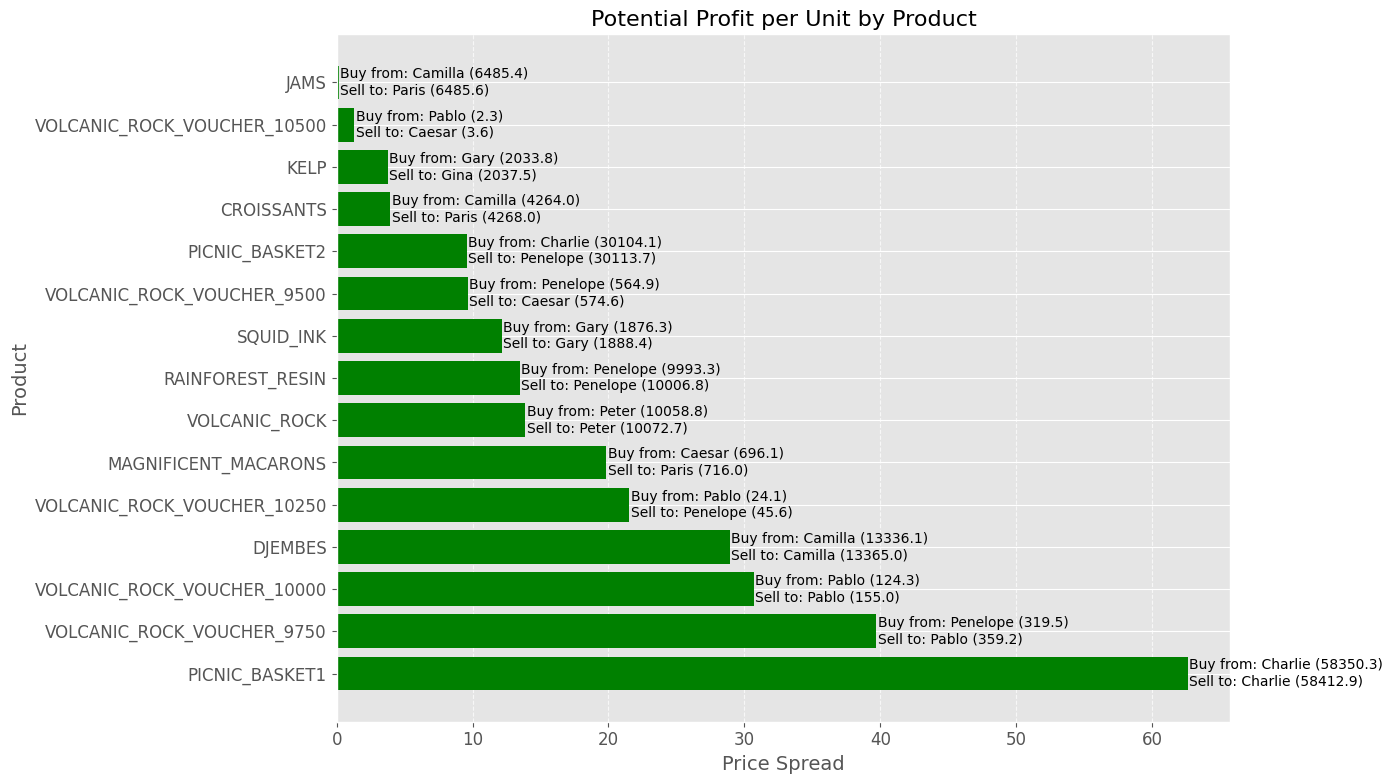

In [15]:
# 7. Generate trading strategy recommendations
print("\n--- Trading Strategy Recommendations ---")

# For each product, identify the best counterparties to trade with
product_recommendations = {}

for product in trades_df['symbol'].unique():
    recommendation = {
        'best_to_sell_to': [],
        'best_to_buy_from': [],
        'ideal_spread': 0
    }
    
    # Find best buyers (to sell to)
    if product in favorable_buyers:
        buyers = [(trader, price) for trader, price in favorable_buyers[product].items()]
        if buyers:
            recommendation['best_to_sell_to'] = sorted(buyers, key=lambda x: x[1], reverse=True)[:3]
    
    # Find best sellers (to buy from)
    if product in favorable_sellers:
        sellers = [(trader, price) for trader, price in favorable_sellers[product].items()]
        if sellers:
            recommendation['best_to_buy_from'] = sorted(sellers, key=lambda x: x[1])[:3]
    
    # Calculate ideal spread if we have both buyers and sellers
    if recommendation['best_to_sell_to'] and recommendation['best_to_buy_from']:
        best_buy_price = recommendation['best_to_buy_from'][0][1]
        best_sell_price = recommendation['best_to_sell_to'][0][1]
        recommendation['ideal_spread'] = best_sell_price - best_buy_price
    
    product_recommendations[product] = recommendation

# Print recommendations
for product, rec in product_recommendations.items():
    print(f"\n=== {product} ===")
    
    if rec['best_to_sell_to']:
        print("Best traders to sell to:")
        for trader, price in rec['best_to_sell_to']:
            print(f"  {trader}: {price:.2f}")
    
    if rec['best_to_buy_from']:
        print("Best traders to buy from:")
        for trader, price in rec['best_to_buy_from']:
            print(f"  {trader}: {price:.2f}")
    
    if rec['ideal_spread'] > 0:
        print(f"Potential profit per unit: {rec['ideal_spread']:.2f}")
    elif rec['ideal_spread'] < 0:
        print(f"Warning: negative spread of {rec['ideal_spread']:.2f} - market may be inverted")

# Generate a recommendations dataframe for visualization
viz_data = []
for product, rec in product_recommendations.items():
    if rec['best_to_sell_to'] and rec['best_to_buy_from'] and rec['ideal_spread'] > 0:
        viz_data.append({
            'Product': product,
            'Best Buyer': rec['best_to_sell_to'][0][0],
            'Buy Price': rec['best_to_sell_to'][0][1],
            'Best Seller': rec['best_to_buy_from'][0][0],
            'Sell Price': rec['best_to_buy_from'][0][1],
            'Spread': rec['ideal_spread']
        })

if viz_data:
    # Create a DataFrame for visualization
    viz_df = pd.DataFrame(viz_data)
    viz_df = viz_df.sort_values('Spread', ascending=False)
    
    # Plot the top profitable products
    plt.figure(figsize=(14, 8))
    ax = plt.barh(viz_df['Product'], viz_df['Spread'], color='green')
    plt.title('Potential Profit per Unit by Product', fontsize=16)
    plt.xlabel('Price Spread', fontsize=14)
    plt.ylabel('Product', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add buyer and seller annotations
    for i, (idx, row) in enumerate(viz_df.iterrows()):
        plt.text(row['Spread'] + 0.1, i, 
                 f"Buy from: {row['Best Seller']} ({row['Sell Price']:.1f})\nSell to: {row['Best Buyer']} ({row['Buy Price']:.1f})", 
                 va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [16]:
# 8. Generate a summary of trader behavior patterns
print("\n--- Trader Behavior Patterns ---")

# Combine all the analyses to generate recommendations
trader_profiles = {}

for trader in set(trades_df['buyer'].unique()) | set(trades_df['seller'].unique()):
    profile = {
        'buys': {},
        'sells': {},
        'total_buys': trader_activity.get('Buy Count', {}).get(trader, 0),
        'total_sells': trader_activity.get('Sell Count', {}).get(trader, 0),
        'buy_volume': trading_volume.get('Buy Volume', {}).get(trader, 0),
        'sell_volume': trading_volume.get('Sell Volume', {}).get(trader, 0),
        'favorite_products_to_buy': top_buy_products.get(trader, []),
        'favorite_products_to_sell': top_sell_products.get(trader, [])
    }
    
    # Add price tendencies
    for product in trades_df['symbol'].unique():
        # Buy price tendencies
        if product in favorable_buyers and trader in favorable_buyers[product]:
            buy_price = favorable_buyers[product][trader]
            market_avg = market_avg_price[product]
            price_ratio = buy_price / market_avg
            profile['buys'][product] = {
                'avg_price': buy_price,
                'vs_market': f"{(price_ratio - 1) * 100:.2f}%"
            }
        
        # Sell price tendencies
        if product in favorable_sellers and trader in favorable_sellers[product]:
            sell_price = favorable_sellers[product][trader]
            market_avg = market_avg_price[product]
            price_ratio = sell_price / market_avg
            profile['sells'][product] = {
                'avg_price': sell_price,
                'vs_market': f"{(price_ratio - 1) * 100:.2f}%"
            }
    
    trader_profiles[trader] = profile

# Print trader profiles
for trader, profile in trader_profiles.items():
    print(f"\n=== {trader} ===")
    print(f"Total buys: {profile['total_buys']}, Total sells: {profile['total_sells']}")
    print(f"Buy volume: {profile['buy_volume']}, Sell volume: {profile['sell_volume']}")
    
    if profile['favorite_products_to_buy']:
        print(f"Favorite products to buy: {', '.join(profile['favorite_products_to_buy'])}")
    
    if profile['favorite_products_to_sell']:
        print(f"Favorite products to sell: {', '.join(profile['favorite_products_to_sell'])}")
    
    if profile['buys']:
        print("\nBuying tendencies (products with above-market prices):")
        for product, data in profile['buys'].items():
            print(f"  {product}: {data['avg_price']:.2f} ({data['vs_market']} above market)")
    
    if profile['sells']:
        print("\nSelling tendencies (products with below-market prices):")
        for product, data in profile['sells'].items():
            print(f"  {product}: {data['avg_price']:.2f} ({data['vs_market']} below market)")


--- Trader Behavior Patterns ---

=== Paris ===
Total buys: 10512.0, Total sells: 12135
Buy volume: 29531.0, Sell volume: 31965
Favorite products to buy: JAMS, CROISSANTS, DJEMBES
Favorite products to sell: JAMS, CROISSANTS, DJEMBES

Buying tendencies (products with above-market prices):
  CROISSANTS: 4268.00 (0.05% above market)
  RAINFOREST_RESIN: 10003.97 (0.04% above market)
  JAMS: 6485.55 (0.00% above market)
  KELP: 2036.40 (0.06% above market)
  SQUID_INK: 1883.84 (0.16% above market)
  MAGNIFICENT_MACARONS: 715.99 (1.01% above market)
  DJEMBES: 13343.12 (0.01% above market)

Selling tendencies (products with below-market prices):
  CROISSANTS: 4265.09 (-0.02% below market)
  RAINFOREST_RESIN: 9996.06 (-0.04% below market)
  KELP: 2034.16 (-0.05% below market)
  SQUID_INK: 1879.71 (-0.06% below market)

=== Pablo ===
Total buys: 2141.0, Total sells: 5672
Buy volume: 6750.0, Sell volume: 30151
Favorite products to buy: RAINFOREST_RESIN, PICNIC_BASKET1, KELP
Favorite products t

In [17]:
# 9. Final Recommendations
print("\n=== FINAL RECOMMENDATIONS ===\n")
print("1. Target specific counterparties for each product based on their historical behavior")
print("2. Leverage price discrepancies between different traders on the same product")
print("3. Adjust trading thresholds based on counterparty identity")
print("4. Track and update counterparty behavior throughout trading")
print("5. Use position management to avoid hitting limits")
print("\nKey counterparties to focus on:")

# List top traders by volume
top_traders = trading_volume.sort_values('Total Volume', ascending=False).head(3).index.tolist()
for trader in top_traders:
    profile = trader_profiles[trader]
    print(f"\n{trader}:")
    if profile['favorite_products_to_buy']:
        print(f"  Buy focus: {', '.join(profile['favorite_products_to_buy'][:3])}")
    if profile['favorite_products_to_sell']:
        print(f"  Sell focus: {', '.join(profile['favorite_products_to_sell'][:3])}")
    
    # Highlight trading opportunities
    opportunities = []
    
    for product in trades_df['symbol'].unique():
        if product in profile['buys'] and float(profile['buys'][product]['vs_market'].replace('%', '')) > 0.5:
            opportunities.append(f"Sell {product} to them (buys {profile['buys'][product]['vs_market']} above market)")
        if product in profile['sells'] and float(profile['sells'][product]['vs_market'].replace('%', '')) < -0.5:
            opportunities.append(f"Buy {product} from them (sells {profile['sells'][product]['vs_market']} below market)")
    
    if opportunities:
        print("  Opportunities:")
        for opp in opportunities[:3]:  # Show top 3 opportunities
            print(f"    - {opp}")


=== FINAL RECOMMENDATIONS ===

1. Target specific counterparties for each product based on their historical behavior
2. Leverage price discrepancies between different traders on the same product
3. Adjust trading thresholds based on counterparty identity
4. Track and update counterparty behavior throughout trading
5. Use position management to avoid hitting limits

Key counterparties to focus on:

Caesar:
  Buy focus: JAMS, CROISSANTS, VOLCANIC_ROCK
  Sell focus: VOLCANIC_ROCK_VOUCHER_10000, VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500
  Opportunities:
    - Buy MAGNIFICENT_MACARONS from them (sells -1.79% below market)
    - Buy VOLCANIC_ROCK_VOUCHER_10000 from them (sells -4.01% below market)
    - Buy VOLCANIC_ROCK_VOUCHER_10250 from them (sells -4.57% below market)

Camilla:
  Buy focus: VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500, VOLCANIC_ROCK_VOUCHER_10000
  Sell focus: JAMS, VOLCANIC_ROCK_VOUCHER_9750, VOLCANIC_ROCK_VOUCHER_9500
  Opportunities:
    - Buy 

---


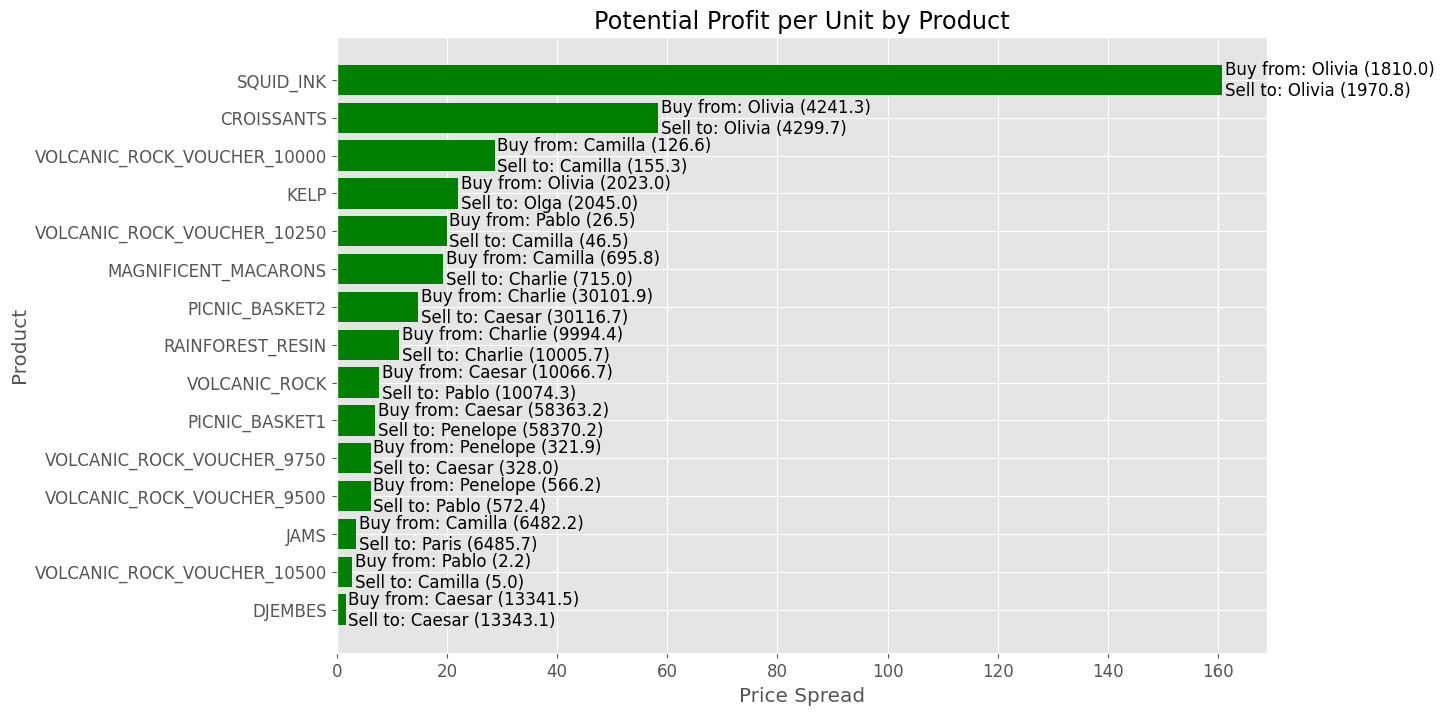

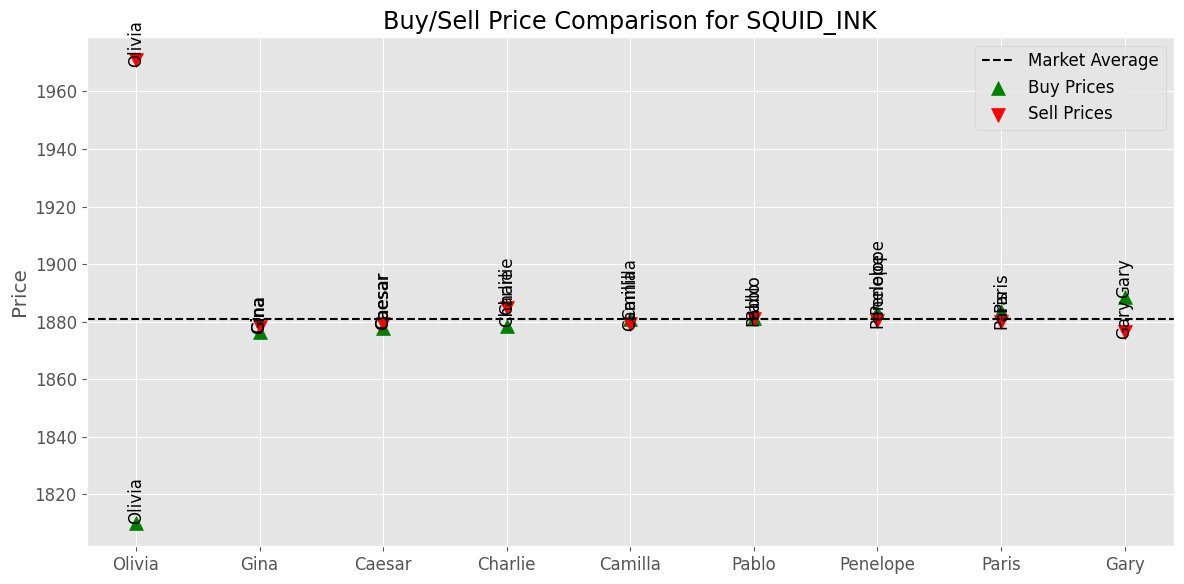

In [27]:
df = trades_df

# Compute profit opportunities per product by identifying best buy and sell traders
buy_prices = df.groupby(['symbol', 'buyer'])['price'].mean().reset_index()
sell_prices = df.groupby(['symbol', 'seller'])['price'].mean().reset_index()

# Merge and compute spreads
best_buy = buy_prices.loc[buy_prices.groupby('symbol')['price'].idxmin()].rename(columns={'buyer': 'buy_from', 'price': 'buy_price'})
best_sell = sell_prices.loc[sell_prices.groupby('symbol')['price'].idxmax()].rename(columns={'seller': 'sell_to', 'price': 'sell_price'})

profit_df = pd.merge(best_buy, best_sell, on='symbol')
profit_df['profit_per_unit'] = profit_df['sell_price'] - profit_df['buy_price']
profit_df = profit_df.sort_values(by='profit_per_unit', ascending=True)

# Plot 1: Profit per unit opportunity across products
fig1, ax1 = plt.subplots(figsize=(12, 8))
bars = ax1.barh(profit_df['symbol'], profit_df['profit_per_unit'], color='green')
ax1.set_title("Potential Profit per Unit by Product")
ax1.set_xlabel("Price Spread")
ax1.set_ylabel("Product")
for i, bar in enumerate(bars):
    symbol = profit_df.iloc[i]['symbol']
    b = profit_df.iloc[i]
    label = f"Buy from: {b['buy_from']} ({b['buy_price']:.1f})\nSell to: {b['sell_to']} ({b['sell_price']:.1f})"
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, label, va='center')

# Plot 2: Buy/Sell price comparison for a single product
target_symbol = "SQUID_INK"
buy_prices_s = buy_prices[buy_prices['symbol'] == target_symbol].sort_values(by='price')
sell_prices_s = sell_prices[sell_prices['symbol'] == target_symbol].sort_values(by='price')
market_avg = df[df['symbol'] == target_symbol]['price'].mean()

fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.axhline(market_avg, color='k', linestyle='--', label='Market Average')
ax2.scatter(buy_prices_s['buyer'], buy_prices_s['price'], color='green', label='Buy Prices', marker='^', s=100)
ax2.scatter(sell_prices_s['seller'], sell_prices_s['price'], color='red', label='Sell Prices', marker='v', s=100)

for i in range(len(buy_prices_s)):
    ax2.text(buy_prices_s['buyer'].iloc[i], buy_prices_s['price'].iloc[i] + 1, buy_prices_s['buyer'].iloc[i], rotation=90, ha='center')
for i in range(len(sell_prices_s)):
    ax2.text(sell_prices_s['seller'].iloc[i], sell_prices_s['price'].iloc[i] - 1, sell_prices_s['seller'].iloc[i], rotation=90, ha='center')

ax2.set_title(f"Buy/Sell Price Comparison for {target_symbol}")
ax2.set_ylabel("Price")
ax2.legend()
plt.tight_layout()
plt.show()


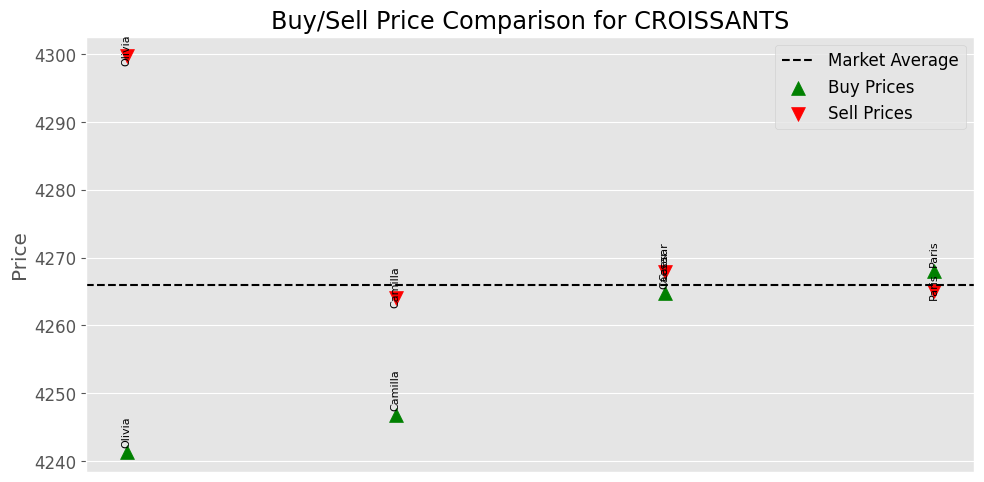

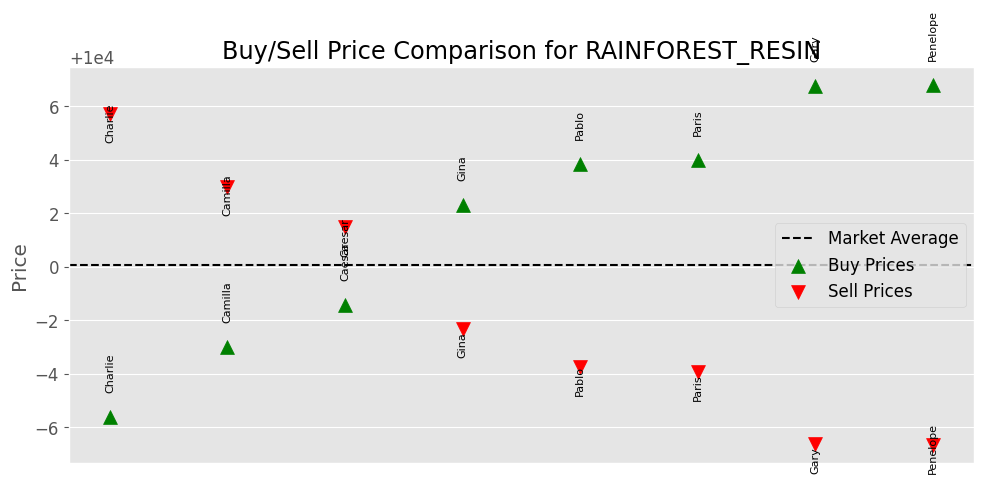

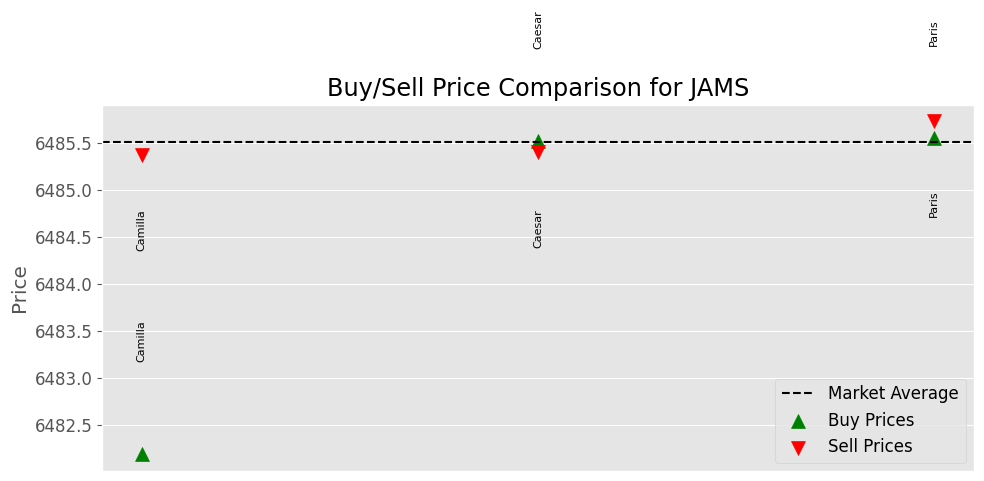

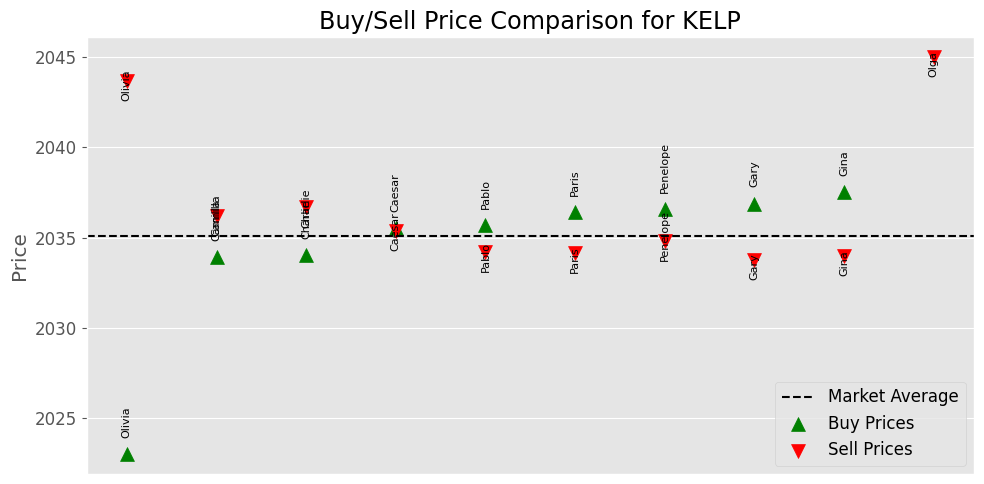

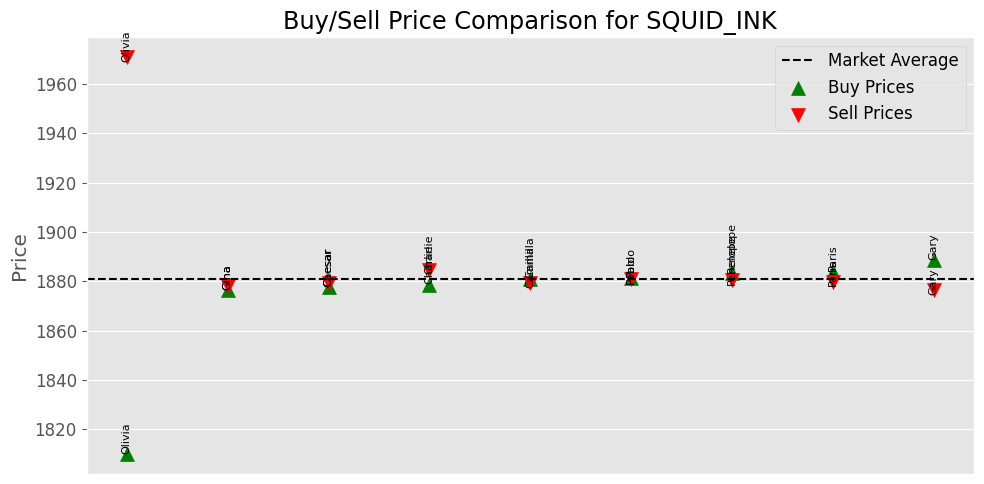

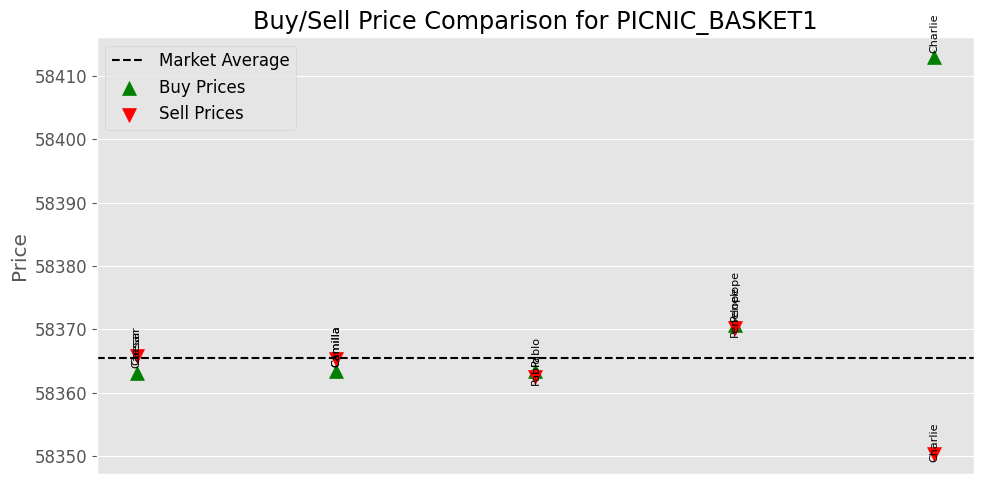

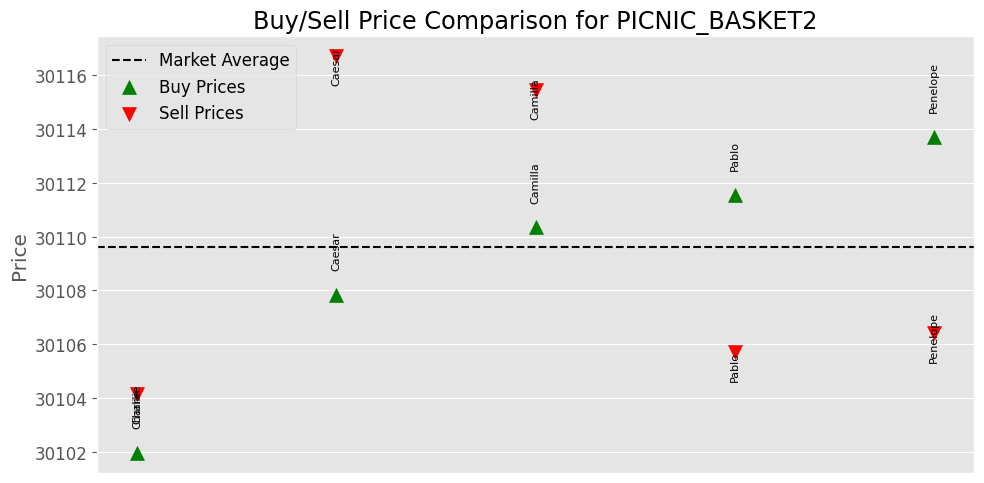

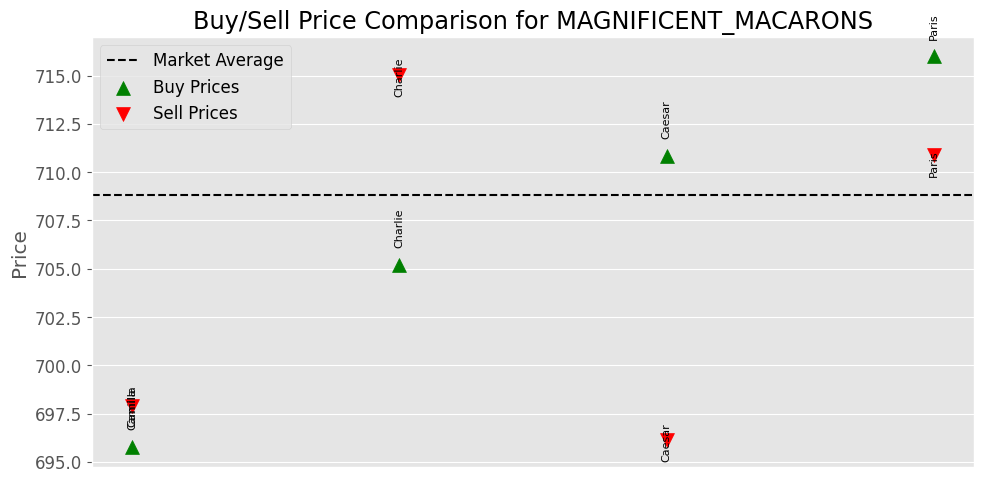

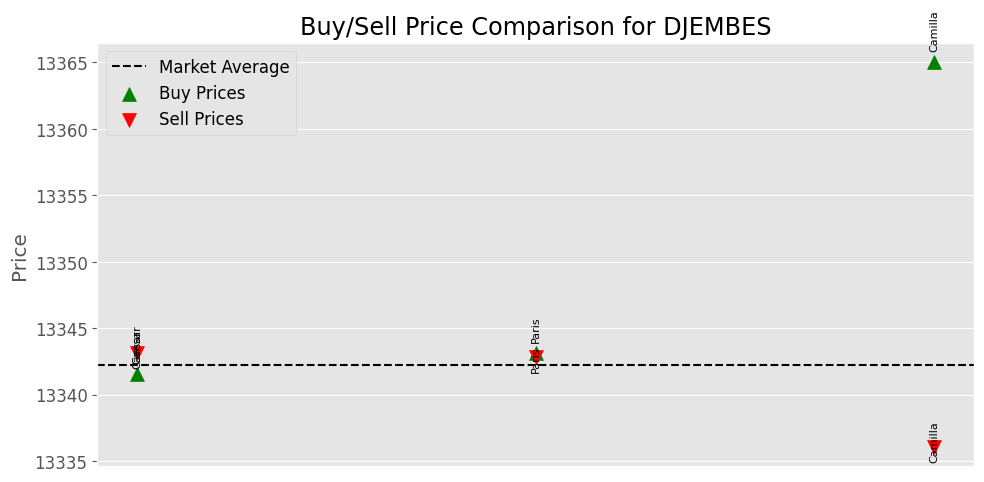

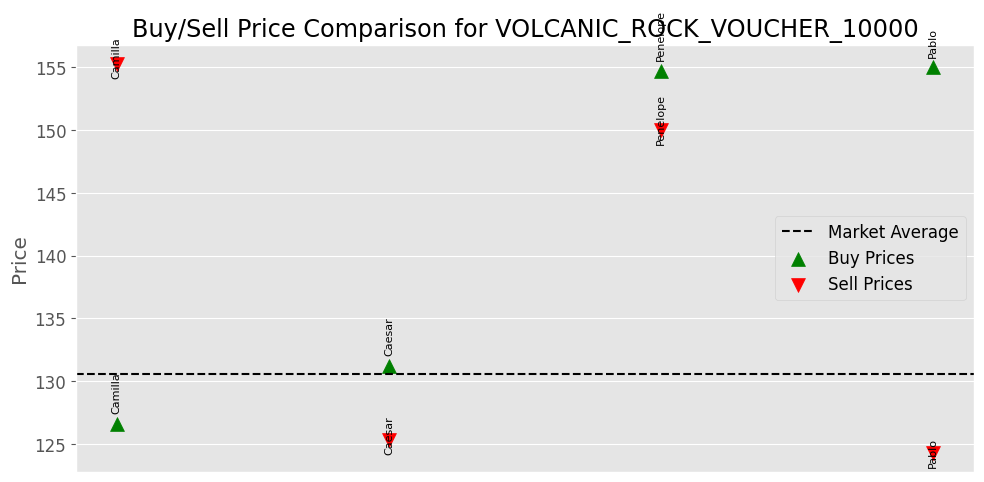

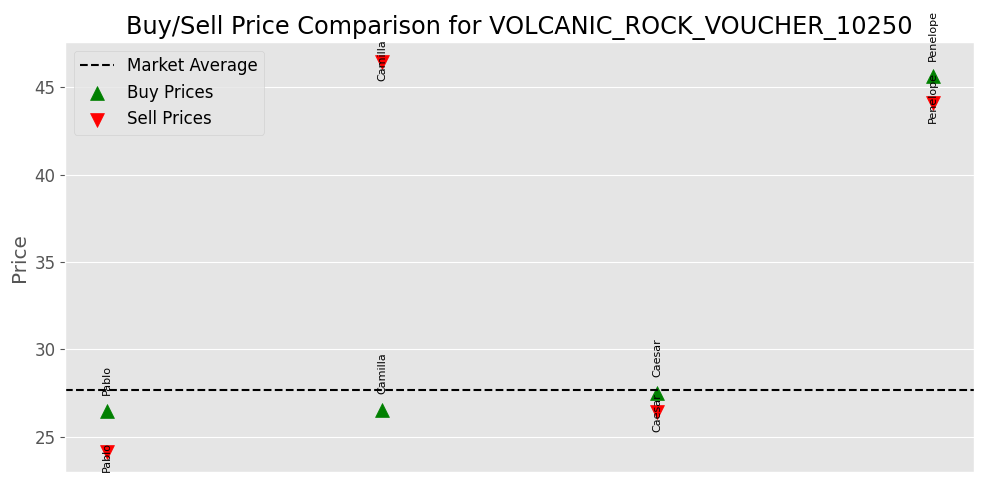

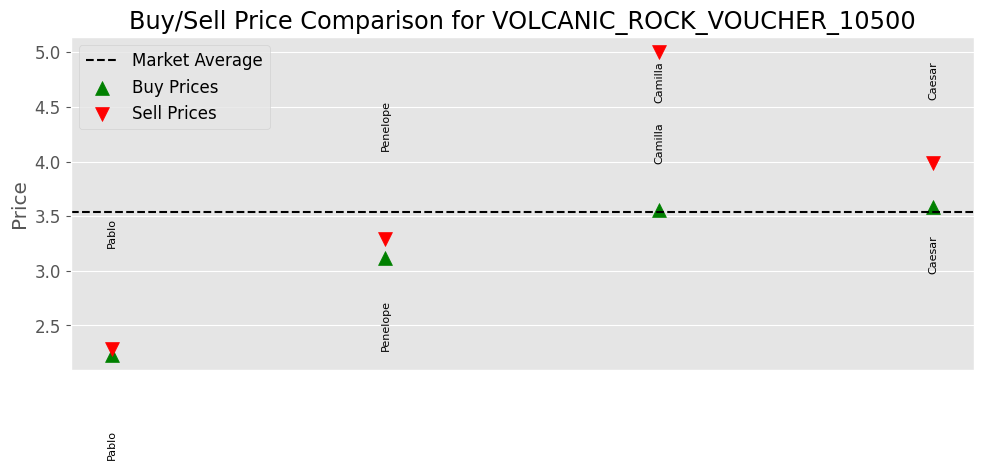

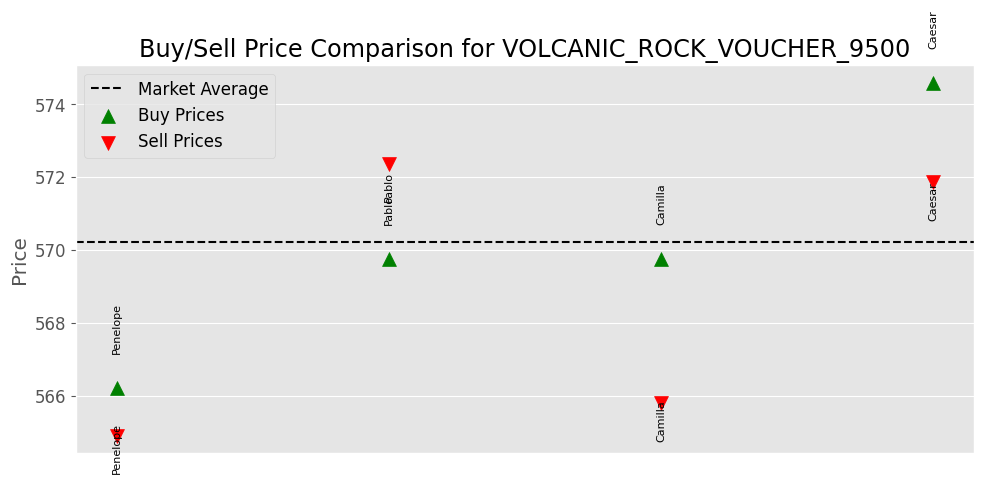

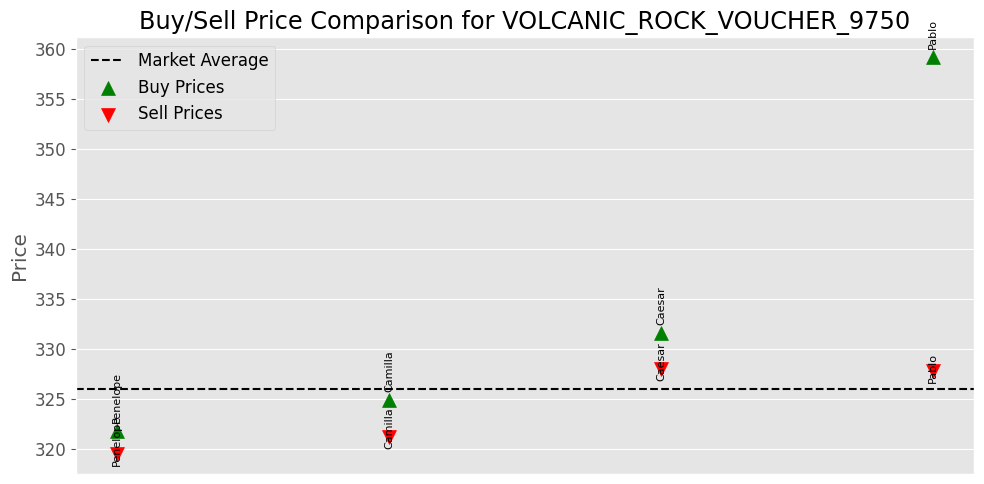

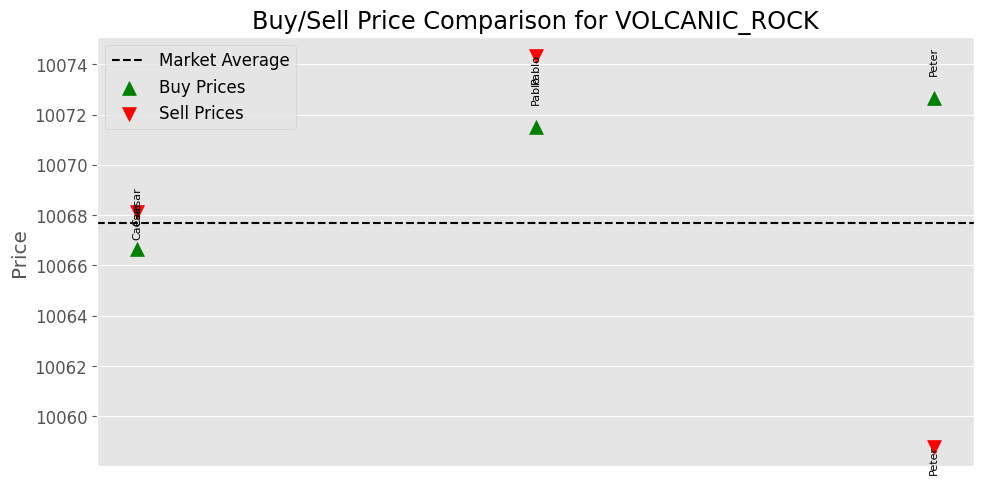

In [28]:
# Generate comparison plots for all unique symbols
unique_symbols = df['symbol'].unique()

# Prepare one plot per symbol
figures = []

for symbol in unique_symbols:
    buy_prices_s = buy_prices[buy_prices['symbol'] == symbol].sort_values(by='price')
    sell_prices_s = sell_prices[sell_prices['symbol'] == symbol].sort_values(by='price')
    market_avg = df[df['symbol'] == symbol]['price'].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(market_avg, color='k', linestyle='--', label='Market Average')
    ax.scatter(buy_prices_s['buyer'], buy_prices_s['price'], color='green', label='Buy Prices', marker='^', s=100)
    ax.scatter(sell_prices_s['seller'], sell_prices_s['price'], color='red', label='Sell Prices', marker='v', s=100)

    for i in range(len(buy_prices_s)):
        ax.text(buy_prices_s['buyer'].iloc[i], buy_prices_s['price'].iloc[i] + 1, buy_prices_s['buyer'].iloc[i], rotation=90, ha='center', fontsize=8)
    for i in range(len(sell_prices_s)):
        ax.text(sell_prices_s['seller'].iloc[i], sell_prices_s['price'].iloc[i] - 1, sell_prices_s['seller'].iloc[i], rotation=90, ha='center', fontsize=8)

    ax.set_title(f"Buy/Sell Price Comparison for {symbol}")
    ax.set_ylabel("Price")
    ax.legend()
    ax.set_xticks([])
    plt.tight_layout()
    figures.append(fig)

plt.show()


 Trader-Aware Opportunistic Market Making
🎯 Core Strategy Components
Exploit Price Spread Between Traders

Use the best observed buy prices from aggressive traders (e.g., Olivia, Gary, Camilla).

Quote near sell prices of passive or overpriced traders (e.g., Penelope, Pablo).

This lets you capture wide spreads where others are not reacting fast enough.

Trader-Specific Pricing Bands

Adjust your quoting when certain traders appear:

If Penelope shows up on the buy side → raise your ask.

If Olivia appears on the sell side → drop your bid.

Traders with consistent price inefficiency become your signal sources.

Skew Your Quotes Based on Order Flow

Products like RAINFOREST_RESIN, MACARONS, and PICNIC_BASKETS show consistent directional flow.

Skew your bid/ask prices depending on the volume imbalance and trader patterns.

VOUCHER Arbitrage

Use the best average price spreads (e.g., VOLCANIC_ROCK_VOUCHER_10250) to build a buy-low/sell-high loop.

Identify repeatable arbitrage flows from traders like Pablo (who sells low) to Penelope or Charlie (who buy high).

Avoid Overcrowded Symbols

For assets like VOLCANIC_ROCK, where traders are clustered near fair value, use tight spreads and fast inventory turnover.

Stick to low-latency market making rather than speculative position building.

🔄 Example Strategy Behavior
Let’s say you're quoting for SQUID_INK:

Buy zone: Place bids just above where Olivia or Pablo buys (~1870)

Sell zone: Post asks just below where Gina or Charlie sells (~1885–1890)

If Olivia takes your low offer → great, your margin is already built in.

💡 Key Edge: Trader Predictability
By anchoring to the most exploitable trader behaviors:

You reduce inventory risk (you know who’s coming)

You raise fill probabilities (you quote where they trade)

You ensure positive expected value per unit trade

In [21]:
import pandas as pd

def load_trade_data(file_list):
    offset = 0
    dfs = []

    for file in file_list:
        df = pd.read_csv(file, delimiter=';')
        df['timestamp'] = df['timestamp'].astype(int) + offset
        offset = df['timestamp'].max() + 100
        dfs.append(df)

    trades = pd.concat(dfs, ignore_index=True)

    # Ensure numeric
    trades['price'] = pd.to_numeric(trades['price'], errors='coerce')
    trades['quantity'] = pd.to_numeric(trades['quantity'], errors='coerce')
    trades['value'] = trades['price'] * trades['quantity']  # Trade value

    return trades

file_list = [
    "data/trades_round_5_day_2.csv",
    "data/trades_round_5_day_3.csv",
    "data/trades_round_5_day_4.csv"
]

df = load_trade_data(file_list)


In [22]:
# Number of trades, total volume, and value per buyer/seller
buyer_summary = df.groupby('buyer').agg(
    num_buys=('quantity', 'count'),
    total_buy_volume=('quantity', 'sum'),
    total_buy_value=('value', 'sum')
).reset_index()

seller_summary = df.groupby('seller').agg(
    num_sells=('quantity', 'count'),
    total_sell_volume=('quantity', 'sum'),
    total_sell_value=('value', 'sum')
).reset_index()

# Merge both to see dual roles
trader_summary = pd.merge(buyer_summary, seller_summary, left_on='buyer', right_on='seller', how='outer')
trader_summary['trader'] = trader_summary['buyer'].combine_first(trader_summary['seller'])
trader_summary = trader_summary.drop(columns=['buyer', 'seller'])

# Fill NaNs with 0 for people only buying or selling
trader_summary = trader_summary.fillna(0)

# Sort by total trading volume (buy + sell)
trader_summary['total_volume'] = trader_summary['total_buy_volume'] + trader_summary['total_sell_volume']
trader_summary = trader_summary.sort_values(by='total_volume', ascending=False)


In [23]:
# Who trades what the most?
product_trading = df.groupby(['buyer', 'symbol']).agg(
    buy_volume=('quantity', 'sum'),
    buy_value=('value', 'sum')
).reset_index().sort_values(by='buy_volume', ascending=False)

# Top products per buyer
top_products_by_buyer = product_trading.groupby('buyer').apply(
    lambda x: x.sort_values(by='buy_volume', ascending=False).head(3)
).reset_index(drop=True)


In [24]:
trader_summary['aggressiveness_score'] = trader_summary['num_buys'] / (
    trader_summary['num_buys'] + trader_summary['num_sells'] + 1e-6
)

# Normalize between 0 and 1: closer to 1 means more aggressive (buy-heavy)
trader_summary['aggressiveness_label'] = pd.cut(
    trader_summary['aggressiveness_score'],
    bins=[0, 0.4, 0.6, 1],
    labels=['Passive', 'Balanced', 'Aggressive']
)


In [26]:
def describe_trader(name):
    row = trader_summary[trader_summary['trader'] == name]
    top_products = top_products_by_buyer[top_products_by_buyer['buyer'] == name]

    if row.empty:
        print(f"No data found for {name}.")
        return

    print(f"🧾 Summary for {name}:")
    print(f"  - Total Buys: {int(row['num_buys'])} | Volume: {int(row['total_buy_volume'])} | Value: {int(row['total_buy_value'])}")
    print(f"  - Total Sells: {int(row['num_sells'])} | Volume: {int(row['total_sell_volume'])} | Value: {int(row['total_sell_value'])}")
    print(f"  - Aggressiveness: {row['aggressiveness_label'].values[0]} ({row['aggressiveness_score'].values[0]:.2f})")

    print("\n📦 Top traded products:")
    for _, prod in top_products.iterrows():
        print(f"  - {prod['symbol']}: {int(prod['buy_volume'])} units")

# Example
describe_trader("Caesar")


🧾 Summary for Caesar:
  - Total Buys: 12598 | Volume: 55726 | Value: 431079150
  - Total Sells: 16931 | Volume: 132125 | Value: 337006779
  - Aggressiveness: Balanced (0.43)

📦 Top traded products:
  - JAMS: 16280 units
  - CROISSANTS: 12299 units
  - VOLCANIC_ROCK: 10801 units
